# 09. Support Vector Machines (SVM)
**Algorithms implemented:** Support Vector Classification (SVC) with linear/poly/RBF kernels and Support Vector Regression (SVR) with an epsilon-insensitive tube.

**Datasets:** real Breast Cancer data (2 features for the kernel view, 30 features for the accuracy benchmark) and the real Old Faithful geyser data for SVR.


In [1]:
# ---- Core numerical and plotting libraries ----
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---- Dataset + model selection ----
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
# ---- SVM models: classification and regression ----
from sklearn.svm import SVC, SVR
# ---- Evaluation metrics ----
from sklearn.metrics import r2_score, root_mean_squared_error

# Styling setup (consistent look across all notebooks)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 110

np.random.seed(42)
print("SVM modules loaded successfully!")


SVM modules loaded successfully!


## 1. Support Vector Classification (SVC)

### Step-by-Step Algorithm (Support Vector Classification)
1. **Formulate** the soft-margin problem: minimize ½||w||² + C Σ ξ_i subject to y_i(wᵀφ(x_i)+b) ≥ 1 − ξ_i, ξ_i ≥ 0.
2. **Solve** the dual quadratic program with Lagrange multipliers α_i (convex -> global optimum).
3. **Identify support vectors:** training points with α_i > 0; they lie on or inside the margin.
4. **Kernel trick:** replace inner products with K(x_i, x_j) (linear, polynomial, RBF, ...) to model non-linear boundaries.
5. **Predict:** class = sign(Σ α_i y_i K(x_i, x) + b).
6. **Tune** C and γ by cross-validation to balance margin width and violations.

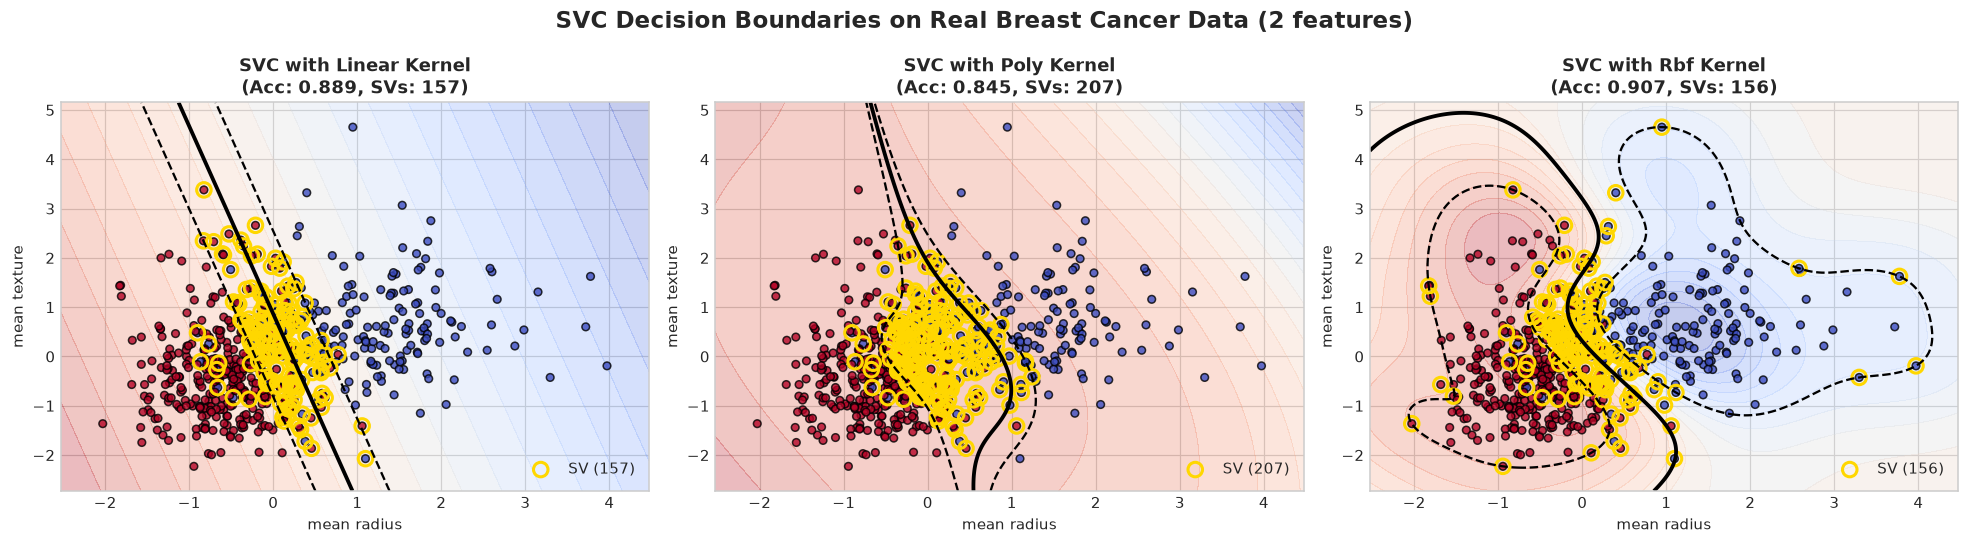

In [2]:
# ---- 2D real data for visualizing margins and kernels ----
# Two diagnostic measurements from the Breast Cancer dataset (malignant vs benign).
cancer_2d = load_breast_cancer()
X_2d = cancer_2d.data[:, [0, 1]]    # mean radius and mean texture
y_2d = cancer_2d.target
feature_names_2d = ['mean radius', 'mean texture']

scaler_2d = StandardScaler()
X_2d_scaled = scaler_2d.fit_transform(X_2d)

kernels = ['linear', 'poly', 'rbf']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Coordinate grid used to draw the decision boundary as a contour
x_min, x_max = X_2d_scaled[:, 0].min() - 0.5, X_2d_scaled[:, 0].max() + 0.5
y_min, y_max = X_2d_scaled[:, 1].min() - 0.5, X_2d_scaled[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))

for ax, k_name in zip(axes, kernels):
    # Train one SVC per kernel on the same real data
    clf = SVC(kernel=k_name, C=1.0, gamma='scale', degree=3, random_state=42)
    clf.fit(X_2d_scaled, y_2d)

    # Signed distance to the hyperplane for every grid point
    Z = clf.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    # Filled contour = decision regions; solid line = boundary (Z=0); dashed = margins (Z=±1)
    ax.contourf(xx, yy, Z, levels=np.linspace(Z.min(), Z.max(), 20), cmap='coolwarm', alpha=0.3)
    ax.contour(xx, yy, Z, levels=[-1.0, 0.0, 1.0], linestyles=['--', '-', '--'], colors=['k', 'k', 'k'], linewidths=[1.5, 2.5, 1.5])

    # Scatter the data points (colored by class)
    ax.scatter(X_2d_scaled[:, 0], X_2d_scaled[:, 1], c=y_2d, cmap='coolwarm', edgecolors='k', s=25, alpha=0.8)

    # Highlight the support vectors (the points that define the margin)
    sv = clf.support_vectors_
    ax.scatter(sv[:, 0], sv[:, 1], s=90, facecolors='none', edgecolors='gold', linewidths=2.0, label=f'SV ({len(sv)})')

    ax.set_title(f"SVC with {k_name.capitalize()} Kernel\n(Acc: {clf.score(X_2d_scaled, y_2d):.3f}, SVs: {len(sv)})", fontweight='bold')
    ax.set_xlabel(feature_names_2d[0])
    ax.set_ylabel(feature_names_2d[1])
    ax.legend(loc='lower right')

plt.suptitle("SVC Decision Boundaries on Real Breast Cancer Data (2 features)", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


In [3]:
# ---- SVC on a real dataset: Breast Cancer (RBF kernel) ----
cancer = load_breast_cancer()
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    cancer.data, cancer.target, test_size=0.25, random_state=42, stratify=cancer.target
)
scaler_c = StandardScaler()
X_train_c_s = scaler_c.fit_transform(X_train_c)
X_test_c_s = scaler_c.transform(X_test_c)

svc_rbf = SVC(kernel='rbf', C=1.0, random_state=42)
svc_rbf.fit(X_train_c_s, y_train_c)
print(f"SVC (RBF) test accuracy on Breast Cancer: {svc_rbf.score(X_test_c_s, y_test_c):.4f}")
print(f"Support vectors used: {len(svc_rbf.support_)} of {len(X_train_c)} training samples")


SVC (RBF) test accuracy on Breast Cancer: 0.9790
Support vectors used: 96 of 426 training samples


## 2. Support Vector Regression (SVR)

### Step-by-Step Algorithm (Support Vector Regression)
1. Define an ε-insensitive tube: residuals with |y_i − f(x_i)| ≤ ε incur zero loss.
2. Minimize ½||w||² + C Σ (ξ_i + ξ_i*) subject to the tube constraints.
3. Solve the dual; only points on/outside the tube get α_i > 0 and become support vectors.
4. **Predict:** f(x) = Σ α_i K(x_i, x) + b (kernel regression).
5. Visualize the fitted curve, the ±ε tube, and the support vectors.

Old Faithful: 272 eruptions | waiting 43-96 min | duration 1.6-5.1 min


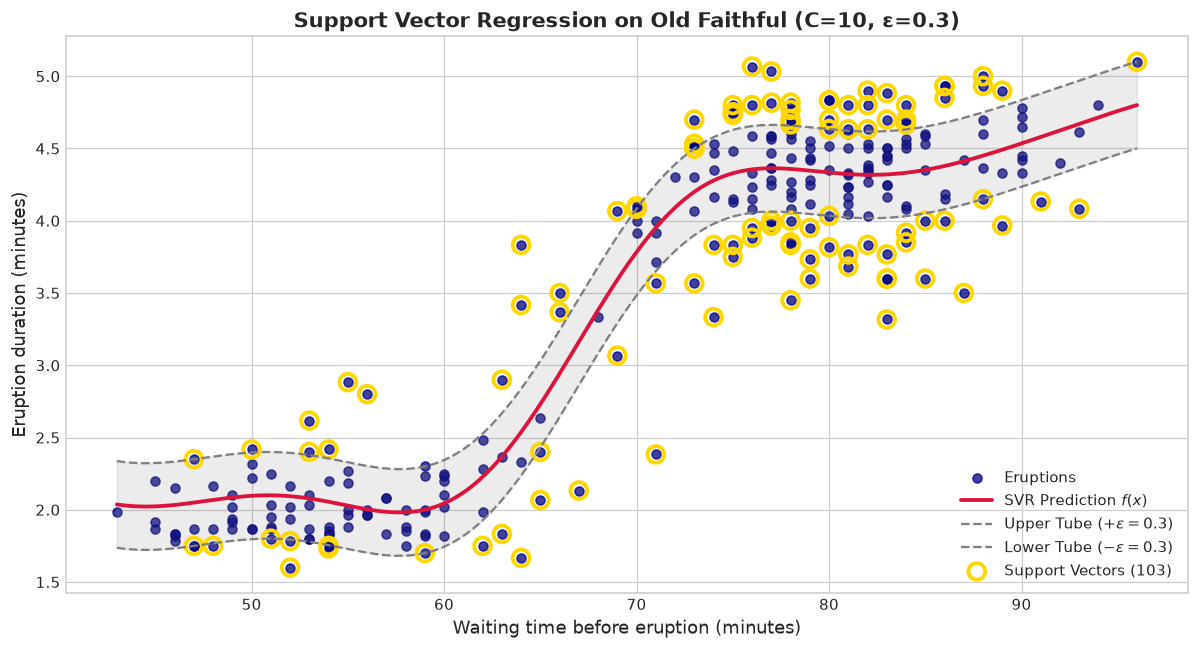

SVR R² Score: 0.8968
SVR RMSE:     0.3660 minutes
Support Vectors: 103 out of 272 points (37.9%)


In [4]:
# ---- Real 1D regression: Old Faithful geyser ----
# x = waiting time before an eruption (minutes), y = eruption duration (minutes)
geyser = pd.read_csv('../data/geyser.csv')
X_svr = geyser['waiting'].values.reshape(-1, 1)
y_svr = geyser['eruptions'].values
print(f"Old Faithful: {len(geyser)} eruptions | waiting {X_svr.min()}-{X_svr.max()} min | duration {y_svr.min()}-{y_svr.max()} min")

# Scale the feature (SVR is distance-based); the target stays in minutes for interpretability
scaler_svr = StandardScaler()
X_svr_scaled = scaler_svr.fit_transform(X_svr)

# epsilon defines the width of the "no penalty" tube around the prediction (in minutes)
epsilon_val = 0.3
svr_model = SVR(kernel='rbf', C=10.0, epsilon=epsilon_val, gamma='scale')
svr_model.fit(X_svr_scaled, y_svr)

# Dense grid for drawing a smooth prediction curve, converted back to minutes
X_grid = np.linspace(X_svr_scaled.min(), X_svr_scaled.max(), 300).reshape(-1, 1)
y_grid_pred = svr_model.predict(X_grid)
X_grid_orig = scaler_svr.inverse_transform(X_grid).ravel()

# Support vectors = training points that lie on/outside the epsilon tube
sv_indices = svr_model.support_
X_sv = X_svr[sv_indices]
y_sv = y_svr[sv_indices]

plt.figure(figsize=(11, 6))
# Training samples
plt.scatter(X_svr, y_svr, color='navy', s=35, alpha=0.75, label='Eruptions')

# Regression surface
plt.plot(X_grid_orig, y_grid_pred, color='crimson', lw=2.5, label='SVR Prediction $f(x)$')

# Epsilon-insensitive tube boundaries + shaded tube
plt.plot(X_grid_orig, y_grid_pred + epsilon_val, color='gray', linestyle='--', lw=1.5, label=rf'Upper Tube ($+\epsilon={epsilon_val}$)')
plt.plot(X_grid_orig, y_grid_pred - epsilon_val, color='gray', linestyle='--', lw=1.5, label=rf'Lower Tube ($-\epsilon={epsilon_val}$)')
plt.fill_between(X_grid_orig, y_grid_pred - epsilon_val, y_grid_pred + epsilon_val, color='gray', alpha=0.15)

# Support vectors are highlighted - only these points influence the fitted curve
plt.scatter(X_sv, y_sv, s=120, facecolors='none', edgecolors='gold', linewidths=2.5, label=f'Support Vectors ({len(X_sv)})')

plt.title(f"Support Vector Regression on Old Faithful (C=10, ε={epsilon_val})", fontsize=14, fontweight='bold')
plt.xlabel("Waiting time before eruption (minutes)", fontsize=12)
plt.ylabel("Eruption duration (minutes)", fontsize=12)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# ---- Quantitative evaluation ----
print(f"SVR R² Score: {r2_score(y_svr, svr_model.predict(X_svr_scaled)):.4f}")
print(f"SVR RMSE:     {root_mean_squared_error(y_svr, svr_model.predict(X_svr_scaled)):.4f} minutes")
print(f"Support Vectors: {len(X_sv)} out of {len(X_svr)} points ({len(X_sv)/len(X_svr)*100:.1f}%)")
